X_train shape : (25000,)
X_test shape  : (25000,)
y_train shape : (25000,)
y_test shape  : (25000,)

Sample Review (Encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 1

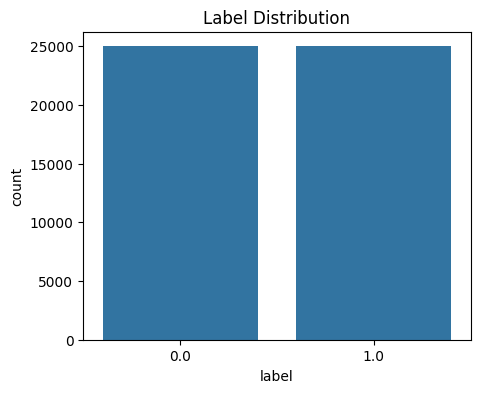


Training Data Shape: (40000, 10000)
Testing Data Shape : (10000, 10000)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 50)                  │         500,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 505,201 (1.93 MB)

 Trainable params: 505,201 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8292 - loss: 0.3940 - val_accuracy: 0.8943 - val_loss: 0.2544
Epoch 2/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9175 - loss: 0.2147 - val_accuracy: 0.8960 - val_loss: 0.2558

Mean Validation Accuracy:
0.8951500058174133
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8960 - loss: 0.2558

Test Loss: 0.2557963728904724
Test Accuracy: 0.8960000276565552


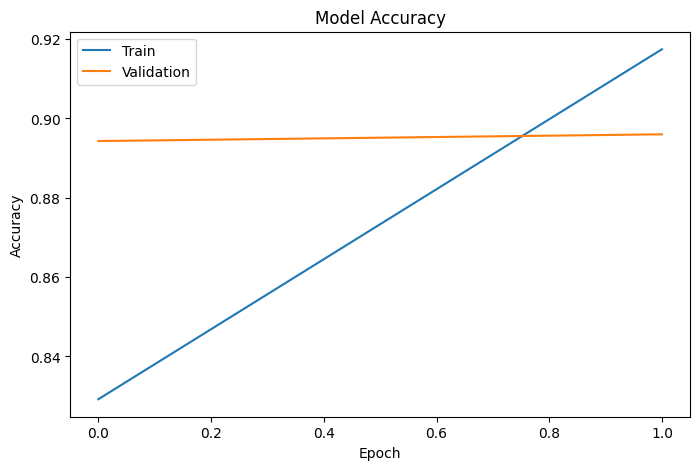

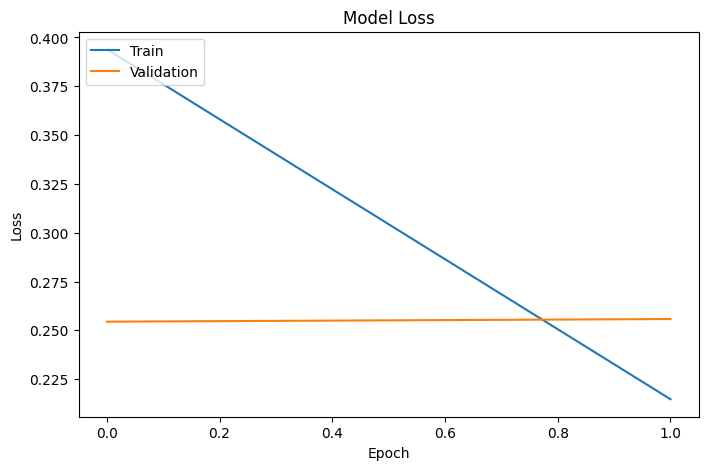

In [2]:
# ============================================
# Sentiment Analysis using DNN on IMDB Dataset
# ============================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import imdb
from keras import models, layers
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ============================================
# Load IMDB Dataset
# ============================================

# Load top 10,000 frequently used words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Combine train and test data
data = np.concatenate((X_train, X_test), axis=0)
label = np.concatenate((y_train, y_test), axis=0)

# ============================================
# Dataset Information
# ============================================

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

# Print one review
print("\nSample Review (Encoded):")
print(X_train[0])

print("\nSample Label:")
print(y_train[0])

# ============================================
# Word Index Dictionary
# ============================================

vocab = imdb.get_word_index()

print("\nTotal Words in Vocabulary:", len(vocab))

# ============================================
# Vectorization Function
# ============================================

# Convert integer sequences into binary vectors
def vectorize(sequences, dimension=10000):

    # Create all-zero matrix
    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

# ============================================
# Exploratory Data Analysis
# ============================================

print("\nCategories:", np.unique(label))

print(
    "Number of unique words:",
    len(np.unique(np.hstack(data)))
)

# Review lengths
length = [len(i) for i in data]

print("Average Review Length:", np.mean(length))
print("Standard Deviation:", round(np.std(length)))

# ============================================
# Decode Review Back to Text
# ============================================

index = imdb.get_word_index()

# Reverse dictionary (index -> word)
reverse_index = dict(
    [(value, key) for (key, value) in index.items()]
)

decoded_review = " ".join(
    [reverse_index.get(i - 3, "#") for i in data[0]]
)

print("\nDecoded Review:\n")
print(decoded_review)

# ============================================
# Vectorize Data
# ============================================

data = vectorize(data)

# Convert labels to float32
label = np.array(label).astype("float32")

# ============================================
# Plot Label Distribution
# ============================================

labelDF = pd.DataFrame({'label': label})

plt.figure(figsize=(5,4))
sns.countplot(x='label', data=labelDF)
plt.title("Label Distribution")
plt.show()

# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    data,
    label,
    test_size=0.20,
    random_state=1
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

# ============================================
# Build Deep Neural Network
# ============================================

model = models.Sequential()

# Input Layer
model.add(
    layers.Dense(
        50,
        activation="relu",
        input_shape=(10000,)
    )
)

# Hidden Layer 1
model.add(layers.Dropout(0.3))

# Hidden Layer 2
model.add(layers.Dense(50, activation="relu"))

# Dropout Layer
model.add(layers.Dropout(0.2))

# Hidden Layer 3
model.add(layers.Dense(50, activation="relu"))

# Output Layer
model.add(layers.Dense(1, activation="sigmoid"))

# ============================================
# Model Summary
# ============================================

model.summary()

# ============================================
# Early Stopping
# ============================================

callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3
)

# ============================================
# Compile Model
# ============================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================
# Train Model
# ============================================

results = model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=500,
    validation_data=(X_test, y_test),
    callbacks=[callback]
)

# ============================================
# Validation Accuracy
# ============================================

print("\nMean Validation Accuracy:")
print(np.mean(results.history["val_accuracy"]))

# ============================================
# Evaluate Model
# ============================================

score = model.evaluate(
    X_test,
    y_test,
    batch_size=500
)

print("\nTest Loss:", score[0])
print("Test Accuracy:", score[1])

# ============================================
# Plot Accuracy Graph
# ============================================

plt.figure(figsize=(8,5))

plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# ============================================
# Plot Loss Graph
# ============================================

plt.figure(figsize=(8,5))

plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()